Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-4-24e0b258cbc7>:86: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 147ms/step - accuracy: 0.5592 - loss: 0.1092 - val_accuracy: 0.5159 - val_loss: 0.1023
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.7823 - loss: 0.0491 - val_accuracy: 0.6797 - val_loss: 0.0757
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 39s 95ms/step - accuracy: 0.7995 - loss: 0.0427 - val_accuracy: 0.7659 - val_loss: 0.0519
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - accuracy: 0.8092 - loss: 0.0361 - val_accuracy: 0.8290 - val_loss: 0.0361
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - accuracy: 0.8370 - loss: 0.0348 - val_accuracy: 0.8442 - val_loss: 0.0307
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - accuracy: 0.8381 - loss: 0.0320 - val_accuracy: 0.8529 - val_loss: 0.0285
Epoch 7/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - accuracy: 0.8451 - loss: 0.0296 - val_accuracy: 0.8638 - val_loss: 0.0281
Epoch 8/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - accuracy: 0.8619 - loss: 0.0284 -

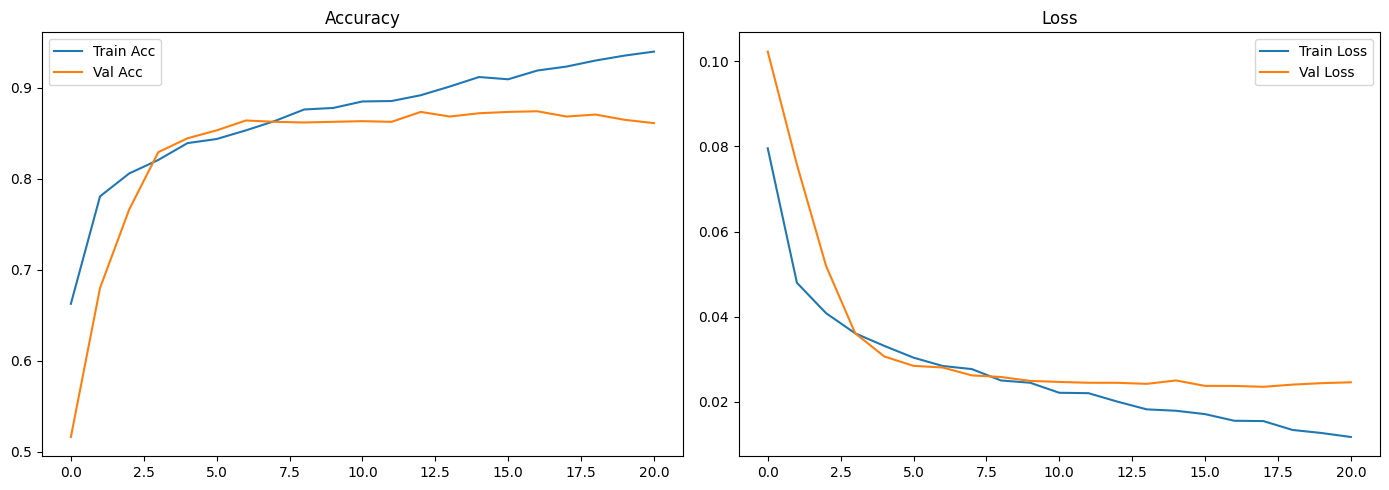

In [ ]:
from google.colab import drive
import os
import tensorflow as tf
import tensorflow.keras.backend as K
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# ربط Google Drive
drive.mount('/content/drive')

# إعداد المسارات
TRAIN_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Train"
VAL_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Validation"
IMG_SIZE = (600, 600)
BATCH_SIZE = 16

# تصنيف الفئات
classes = sorted(os.listdir(TRAIN_PATH))

# دالة التحميل والمعالجة عبر OpenCV
def load_and_preprocess(path, label):
    path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.merge([img, img, img]).astype('float32') / 255.0
    return img, label

# دالة لتحويلها لـ TensorFlow
def tf_load_and_preprocess(path, label):
    img, lbl = tf.numpy_function(load_and_preprocess, [path, label], [tf.float32, tf.int32])
    img.set_shape([*IMG_SIZE, 3])
    lbl.set_shape([])
    lbl = tf.one_hot(lbl, depth=len(classes))
    return img, lbl

# تحميل المسارات والتصنيفات من مجلد معين
def load_dataset_from_folder(base_path):
    file_paths, labels = [], []
    for idx, cls in enumerate(classes):
        cls_folder = os.path.join(base_path, cls)
        for fname in os.listdir(cls_folder):
            file_paths.append(os.path.join(cls_folder, fname))
            labels.append(idx)
    return file_paths, labels

# تحميل بيانات التدريب والتحقق
train_files, train_labels = load_dataset_from_folder(TRAIN_PATH)
val_files, val_labels = load_dataset_from_folder(VAL_PATH)

# بناء Datasets مع Augmentation خفيف فقط
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (tf.image.random_flip_left_right(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# دالة فوكال لوس
def focal_loss(gamma=2., alpha=0.25):
    def loss_fn(y_true, y_pred):
        eps    = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1. - eps)
        ce     = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * ce, axis=1)
    return loss_fn

# بناء نموذج MobileNetV2 مع Fine-Tuning
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)
for layer in base_model.layers[:-20]:  # فتح عدد أكبر من الطبقات
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)  # تقليل Dropout
outputs = Dense(len(classes), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=outputs)

# تجميع النموذج
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # رفع learning rate قليلاً
    loss=focal_loss(),
    metrics=['accuracy']
)

# EarlyStopping معدل
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# تدريب النموذج
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

# حفظ النموذج والنتائج
model.save("/content/drive/MyDrive/Merged_Mendeley_ViralCovid/MobileNetV2_RecoveryFromUnderfit.h5")
pd.DataFrame(history.history).to_csv(
    "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/MobileNetV2_RecoveryFromUnderfit_results.csv",
    index=False
)

# رسم الأداء
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 136s 289ms/step - accuracy: 0.6804 - loss: 0.0923 - val_accuracy: 0.5094 - val_loss: 0.1199
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 83s 206ms/step - accuracy: 0.7545 - loss: 0.0611 - val_accuracy: 0.6152 - val_loss: 0.1172
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 83s 206ms/step - accuracy: 0.7749 - loss: 0.0568 - val_accuracy: 0.5609 - val_loss: 0.1698
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 83s 206ms/step - accuracy: 0.7746 - loss: 0.0551 - val_accuracy: 0.8152 - val_loss: 0.0449
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 83s 206ms/step - accuracy: 0.7845 - loss: 0.0497 - val_accuracy: 0.4022 - val_loss: 0.4295
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 83s 206ms/step - accuracy: 0.8008 - loss: 0.0460 - val_accuracy: 0.7964 - val_loss: 0.0416
Epoch 7/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 83s 206ms/step - accuracy: 0.7914 - loss: 0.

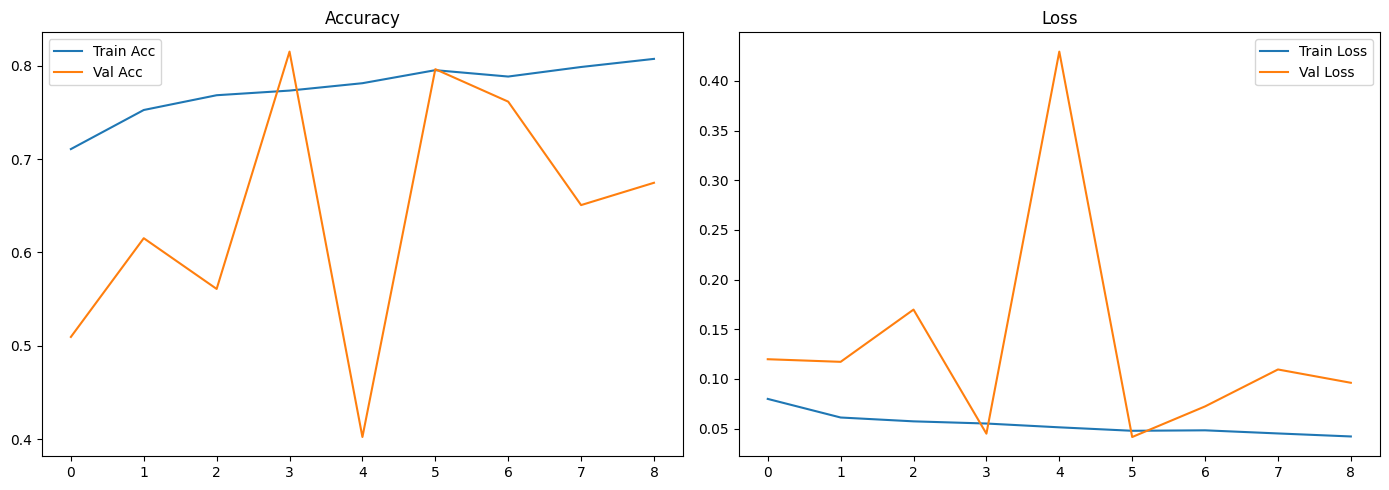

In [ ]:
from google.colab import drive
import os
import tensorflow as tf
import tensorflow.keras.backend as K
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# ربط Google Drive
drive.mount('/content/drive')

# إعداد المسارات
TRAIN_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Train"
VAL_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Validation"
IMG_SIZE = (600, 600)
BATCH_SIZE = 16

# تصنيف الفئات
classes = sorted(os.listdir(TRAIN_PATH))

# دالة التحميل والمعالجة عبر OpenCV
def load_and_preprocess(path, label):
    path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.merge([img, img, img]).astype('float32') / 255.0
    return img, label

# دالة لتحويلها لـ TensorFlow
def tf_load_and_preprocess(path, label):
    img, lbl = tf.numpy_function(load_and_preprocess, [path, label], [tf.float32, tf.int32])
    img.set_shape([*IMG_SIZE, 3])
    lbl.set_shape([])
    lbl = tf.one_hot(lbl, depth=len(classes))
    return img, lbl

# تحميل المسارات والتصنيفات من مجلد معين
def load_dataset_from_folder(base_path):
    file_paths, labels = [], []
    for idx, cls in enumerate(classes):
        cls_folder = os.path.join(base_path, cls)
        for fname in os.listdir(cls_folder):
            file_paths.append(os.path.join(cls_folder, fname))
            labels.append(idx)
    return file_paths, labels

# تحميل بيانات التدريب والتحقق
train_files, train_labels = load_dataset_from_folder(TRAIN_PATH)
val_files, val_labels = load_dataset_from_folder(VAL_PATH)

# اوغمنتيشن
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (tf.image.random_flip_left_right(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# دالة فوكال لوس
def focal_loss(gamma=2., alpha=0.25):
    def loss_fn(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1. - eps)
        ce = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * ce, axis=1)
    return loss_fn

# بناء نموذج ResNet50 مع Fine-Tuning
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)
for layer in base_model.layers[:-30]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(len(classes), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=outputs)

# تجميع النموذج
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=focal_loss(),
    metrics=['accuracy']
)

# EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# تدريب النموذج
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

# حفظ النموذج والنتائج
model.save("/content/drive/MyDrive/Merged_Mendeley_ViralCovid/ResNet_Final_Experiment.h5")
pd.DataFrame(history.history).to_csv(
    "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/ResNet_Final_Experiment_results.csv",
    index=False
)

# رسم الأداء
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 56s 123ms/step - accuracy: 0.6905 - loss: 0.3373 - val_accuracy: 0.4333 - val_loss: 0.2729
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 83ms/step - accuracy: 0.7619 - loss: 0.0478 - val_accuracy: 0.8007 - val_loss: 0.0390
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 83ms/step - accuracy: 0.7730 - loss: 0.0462 - val_accuracy: 0.7964 - val_loss: 0.0345
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.7766 - loss: 0.0412 - val_accuracy: 0.8080 - val_loss: 0.0350
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.7932 - loss: 0.0383 - val_accuracy: 0.8116 - val_loss: 0.0439
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.7847 - loss: 0.0374 - val_accuracy: 0.8007 - val_loss: 0.0510
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


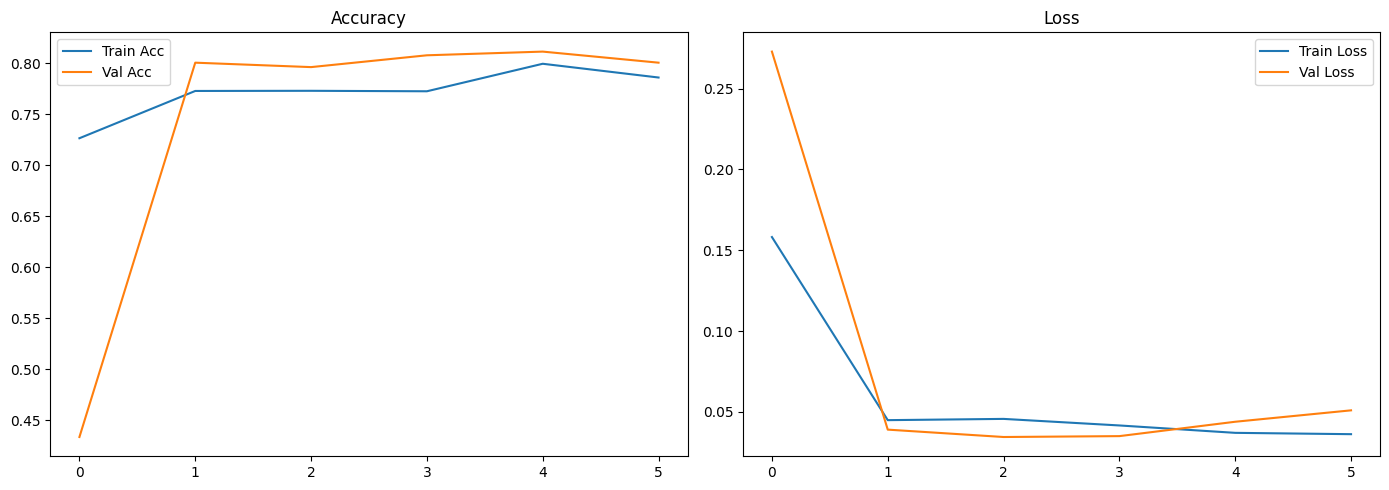

In [ ]:
from google.colab import drive
import os
import tensorflow as tf
import tensorflow.keras.backend as K
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# ربط Google Drive
drive.mount('/content/drive')

# إعداد المسارات
TRAIN_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Train"
VAL_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Validation"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# الفئات
classes = sorted(os.listdir(TRAIN_PATH))

# CLAHE
def load_and_preprocess(path, label):
    path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.merge([img, img, img]).astype('float32') / 255.0
    return img, label

def tf_load_and_preprocess(path, label):
    img, lbl = tf.numpy_function(load_and_preprocess, [path, label], [tf.float32, tf.int32])
    img.set_shape([*IMG_SIZE, 3])
    lbl.set_shape([])
    lbl = tf.one_hot(lbl, depth=len(classes))
    return img, lbl

def load_dataset_from_folder(base_path):
    file_paths, labels = [], []
    for idx, cls in enumerate(classes):
        for fname in os.listdir(os.path.join(base_path, cls)):
            file_paths.append(os.path.join(base_path, cls, fname))
            labels.append(idx)
    return file_paths, labels

train_files, train_labels = load_dataset_from_folder(TRAIN_PATH)
val_files, val_labels = load_dataset_from_folder(VAL_PATH)

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (tf.image.random_flip_left_right(x), y))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# فوكال لوس
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1. - eps)
        ce = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * ce, axis=1)
    return loss

# نموذج CNN كلاسيكي مشروح مثل VGG-like
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(*IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_loss(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

# حفظ النموذج والنتائج
model.save("/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Classic_CNN_VGG_like.h5")
pd.DataFrame(history.history).to_csv(
    "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Classic_CNN_VGG_like_results.csv",
    index=False
)

# رسم الأداء
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 103s 175ms/step - accuracy: 0.6014 - loss: 0.1376 - val_accuracy: 0.7848 - val_loss: 0.0505
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.7521 - loss: 0.0734 - val_accuracy: 0.8246 - val_loss: 0.0419
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.7983 - loss: 0.0530 - val_accuracy: 0.8493 - val_loss: 0.0386
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.8186 - loss: 0.0436 - val_accuracy: 0.8529 - val_loss: 0.0350
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.8263 - loss: 0.0407 - val_accuracy: 0.8514 - val_loss: 0.0347
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.8432 - loss: 0.0341 - val_accuracy: 0.8681 - val_loss: 0.0339
Epoch 7/30
403/403 ━━━━━━━━━━━━━━━━━━━

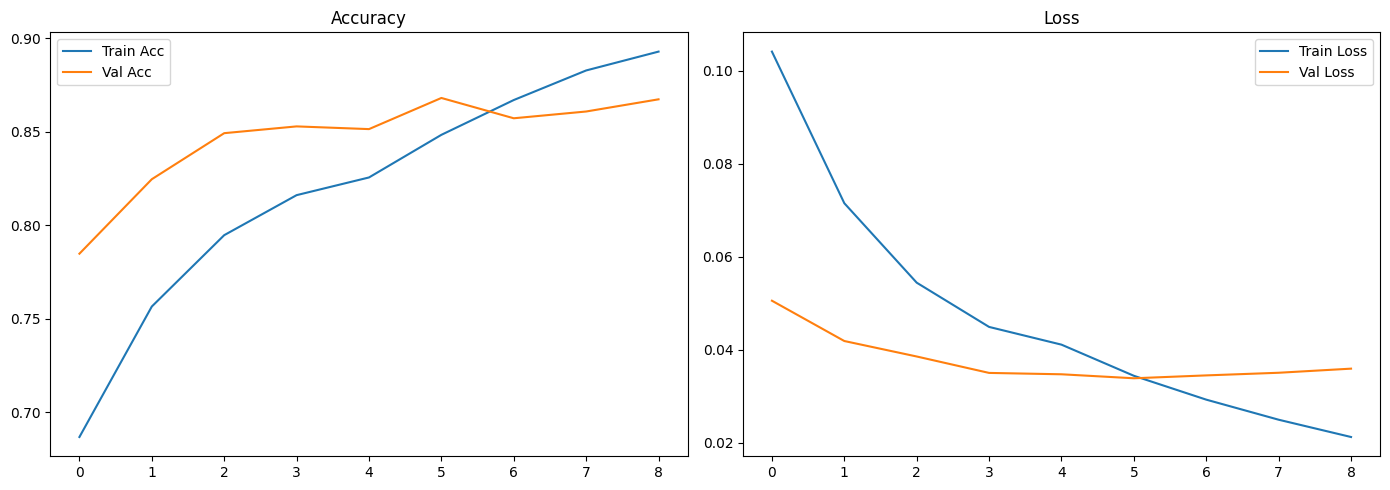

In [ ]:
from google.colab import drive
import os
import tensorflow as tf
import tensorflow.keras.backend as K
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# ربط Google Drive
drive.mount('/content/drive')

# إعداد المسارات
TRAIN_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Train"
VAL_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Validation"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# تصنيف الفئات
classes = sorted(os.listdir(TRAIN_PATH))

# CLAHE
def load_and_preprocess(path, label):
    path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.merge([img, img, img]).astype('float32') / 255.0
    return img, label

def tf_load_and_preprocess(path, label):
    img, lbl = tf.numpy_function(load_and_preprocess, [path, label], [tf.float32, tf.int32])
    img.set_shape([*IMG_SIZE, 3])
    lbl.set_shape([])
    lbl = tf.one_hot(lbl, depth=len(classes))
    return img, lbl

def load_dataset_from_folder(base_path):
    file_paths, labels = [], []
    for idx, cls in enumerate(classes):
        for fname in os.listdir(os.path.join(base_path, cls)):
            file_paths.append(os.path.join(base_path, cls, fname))
            labels.append(idx)
    return file_paths, labels

train_files, train_labels = load_dataset_from_folder(TRAIN_PATH)
val_files, val_labels = load_dataset_from_folder(VAL_PATH)

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (tf.image.random_flip_left_right(x), y))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# فوكال لوس
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1. - eps)
        ce = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * ce, axis=1)
    return loss

# تحميل DenseNet121 مع Fine-Tuning بسيط
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
for layer in base_model.layers[:-20]:  # نترك فقط آخر 20 طبقة للتدريب
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_loss(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

# حفظ النموذج والنتائج
model.save("/content/drive/MyDrive/Merged_Mendeley_ViralCovid/DenseNet121_FastExperiment.h5")
pd.DataFrame(history.history).to_csv(
    "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/DenseNet121_FastExperiment_results.csv",
    index=False
)

# رسم الأداء
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 94s 162ms/step - accuracy: 0.3594 - loss: 0.2722 - val_accuracy: 0.3551 - val_loss: 0.2106
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 83ms/step - accuracy: 0.3924 - loss: 0.2308 - val_accuracy: 0.3239 - val_loss: 0.1241
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.4340 - loss: 0.2069 - val_accuracy: 0.5594 - val_loss: 0.1091
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.4440 - loss: 0.1898 - val_accuracy: 0.3587 - val_loss: 0.2452
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.4247 - loss: 0.1859 - val_accuracy: 0.5145 - val_loss: 0.1081
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 83ms/step - accuracy: 0.4507 - loss: 0.1732 - val_accuracy: 0.3906 - val_loss: 0.1138
Epoch 7/30
403/403 ━━━━━━━━━━━━━━━━━━━━

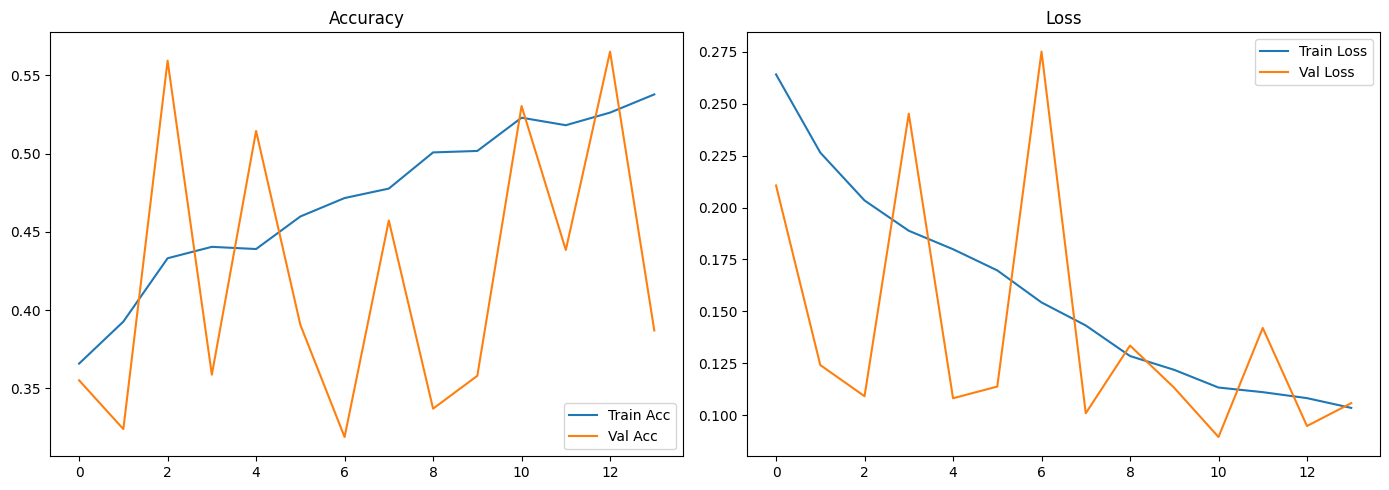

In [ ]:
from google.colab import drive
import os
import tensorflow as tf
import tensorflow.keras.backend as K
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# ربط Google Drive
drive.mount('/content/drive')

# إعداد المسارات
TRAIN_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Train"
VAL_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Validation"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# أسماء الفئات
classes = sorted(os.listdir(TRAIN_PATH))

# CLAHE + تحويل لـ RGB
def load_and_preprocess(path, label):
    path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.merge([img, img, img]).astype('float32') / 255.0
    return img, label

def tf_load_and_preprocess(path, label):
    img, lbl = tf.numpy_function(load_and_preprocess, [path, label], [tf.float32, tf.int32])
    img.set_shape([*IMG_SIZE, 3])
    lbl.set_shape([])
    lbl = tf.one_hot(lbl, depth=len(classes))
    return img, lbl

def load_dataset_from_folder(base_path):
    file_paths, labels = [], []
    for idx, cls in enumerate(classes):
        for fname in os.listdir(os.path.join(base_path, cls)):
            file_paths.append(os.path.join(base_path, cls, fname))
            labels.append(idx)
    return file_paths, labels

train_files, train_labels = load_dataset_from_folder(TRAIN_PATH)
val_files, val_labels = load_dataset_from_folder(VAL_PATH)

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (tf.image.random_flip_left_right(x), y))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# فوكال لوس
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1. - eps)
        ce = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * ce, axis=1)
    return loss

# بناء نموذج EfficientNetB0 مع Fine-Tuning محدود
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
for layer in base_model.layers[:-20]:  # فقط آخر 20 طبقة مفتوحة للتدريب
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_loss(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

# حفظ النموذج والنتائج
model.save("/content/drive/MyDrive/Merged_Mendeley_ViralCovid/EfficientNetB0_MedicalExperiment.h5")
pd.DataFrame(history.history).to_csv(
    "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/EfficientNetB0_MedicalExperiment_results.csv",
    index=False
)

# رسم الأداء
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 106s 171ms/step - accuracy: 0.5987 - loss: 0.1730 - val_accuracy: 0.7377 - val_loss: 0.0765
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.7036 - loss: 0.1139 - val_accuracy: 0.7659 - val_loss: 0.0645
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.7376 - loss: 0.0986 - val_accuracy: 0.7942 - val_loss: 0.0491
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.7607 - loss: 0.0793 - val_accuracy: 0.8072 - val_loss: 0.0471
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.7684 - loss: 0.0688 - val_accuracy: 0.8036 - val_loss: 0.0472
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.7865 - loss: 0.0681 - val_accuracy: 0.8065 - val_loss: 0.0480
Epoch 7/30
403/403 ━━━━━━━━━━━━━━━━━━━

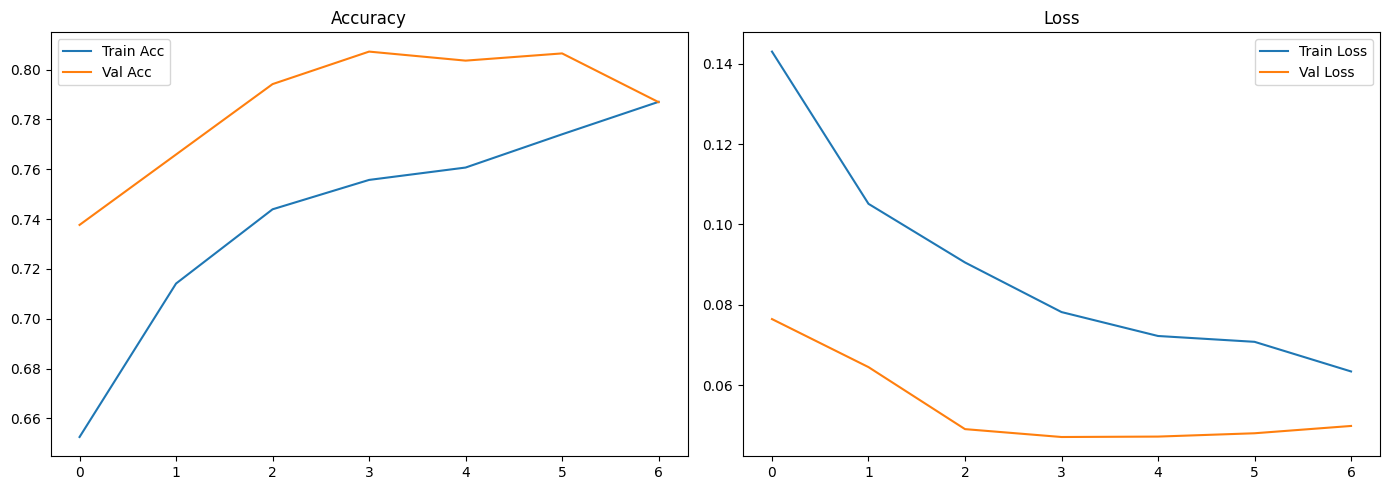

In [ ]:
from google.colab import drive
import os
import tensorflow as tf
import tensorflow.keras.backend as K
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Mount Google Drive
drive.mount('/content/drive')

# Paths and Constants
TRAIN_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Train"
VAL_PATH = "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/Validation"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Classes
classes = sorted(os.listdir(TRAIN_PATH))

# Image Preprocessing with CLAHE
def load_and_preprocess(path, label):
    path = path.decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.merge([img, img, img]).astype('float32') / 255.0
    return img, label

def tf_load_and_preprocess(path, label):
    img, lbl = tf.numpy_function(load_and_preprocess, [path, label], [tf.float32, tf.int32])
    img.set_shape([*IMG_SIZE, 3])
    lbl.set_shape([])
    lbl = tf.one_hot(lbl, depth=len(classes))
    return img, lbl

def load_dataset_from_folder(base_path):
    file_paths, labels = [], []
    for idx, cls in enumerate(classes):
        for fname in os.listdir(os.path.join(base_path, cls)):
            file_paths.append(os.path.join(base_path, cls, fname))
            labels.append(idx)
    return file_paths, labels

# Load Data
train_files, train_labels = load_dataset_from_folder(TRAIN_PATH)
val_files, val_labels = load_dataset_from_folder(VAL_PATH)

# Build Dataset Pipelines
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (tf.image.random_flip_left_right(x), y))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(tf_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Focal Loss Function
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1. - eps)
        ce = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * ce, axis=1)
    return loss

# Build NASNetMobile Model
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
for layer in base_model.layers[:-20]:  # fine-tune last 20 layers
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(len(classes), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_loss(),
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

# Save Model and Results
model.save("/content/drive/MyDrive/Merged_Mendeley_ViralCovid/NASNetMobile_MedicalExperiment.h5")
pd.DataFrame(history.history).to_csv(
    "/content/drive/MyDrive/Merged_Mendeley_ViralCovid/NASNetMobile_MedicalExperiment_results.csv",
    index=False
)

# Plot Results
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()
